In [35]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt

In [36]:
#====================
# Dataset Generation
#====================
np.random.seed(42)

n = 200
X = np.random.uniform(-3 , 3 , n).reshape(-1 , 1)
true_w , true_b = 2.5 , -1.0
noise_sd = 1.5
y = true_w * X.flatten() + true_b + np.random.normal(0 , noise_sd , n)

X_design = np.hstack([X , np.ones((n , 1))])

X_scaled = (X - X.mean()) / X.std()
X_scaled_design = np.hstack([X_scaled , np.ones((n , 1))])

In [37]:
#===================================================================
# Lipschitz estimate for MSE gradient
# f(w) = (1 / n)||Xw - y|| ^ 2 , L = 2 * lambda_max((X ^ T X) / n)
#===================================================================
def estimate_L(Xd):
    H = (2 / n) * (Xd.T @ Xd)
    return float(np.max(np.linalg.eigvals(H).real))

L_orig = estimate_L(X_design)
L_scaled = estimate_L(X_scaled_design)

alpha_1_over_L_orig = 1 / L_orig
alpha_1_over_L_scaled = 1 / L_scaled

#======================================================
# Gradient Descent runner (with divergence detection)
#======================================================
def run_gd(Xd , y , alpha , epochs = 120 , diverge_thresh = 1e6):
    w = np.zeros(Xd.shape[1])
    losses = []
    diverged = False

    for _ in range(epochs):
        grad = (2 / n) * Xd.T @ (Xd @ w - y)
        w = w - alpha * grad
        loss = np.mean((Xd @ w - y) ** 2)
        losses.append(loss)

        if (not np.isfinite(loss)) or (loss > diverge_thresh):
            diverged = True
            break

    return w , losses , diverged

In [38]:
#====================================================================
# Convergence speed metric: epochs to reach within tol of final loss
#====================================================================
def epochs_to_tol(losses , tol = 0.01):
    final = losses[-1]
    target = final * (1 + tol)
    for i , l in enumerate(losses):
        if l <= target:
            return i
    return len(losses)

def alpha_pack(L):
    return {
        "Too small α = 0.1/L": 0.1 / L , "Safe α = 1/L": 1.0 / L ,
        "Border α = 1.8/L": 1.8 / L , "Too large α = 3/L": 3.0 / L ,
    }

In [39]:
epochs = 120
alphas_orig = alpha_pack(L_orig)
alphas_scaled = alpha_pack(L_scaled)

results_orig = {}
results_scaled = {}

for label , a in alphas_orig.items():
    w , losses , div = run_gd(X_design , y , a , epochs = epochs)
    results_orig[label] = {"alpha": a , "w": w , "losses": losses , "diverged": div}

for label , a in alphas_scaled.items():
    w , losses , div = run_gd(X_scaled_design , y , a , epochs = epochs)
    results_scaled[label] = {"alpha": a , "w": w , "losses": losses , "diverged": div}

In [40]:
#===================================
# Distance-to-optimum (delta loss)
#===================================
opt_loss_orig = results_orig["Safe α = 1/L"]["losses"][-1]
opt_loss_scaled = results_scaled["Safe α = 1/L"]["losses"][-1]

def delta_losses(losses , opt_loss):
    return [max(l - opt_loss , 0.0) for l in losses]

ORDER = ["Too small α = 0.1/L" , "Safe α = 1/L" , "Border α = 1.8/L" , "Too large α = 3/L"]

Text(0.5, 1.0, 'Original: Raw Loss vs Epochs — Full View')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'MSE Loss')

Text(8, 10000.0, 'Diverges when α > safe range')

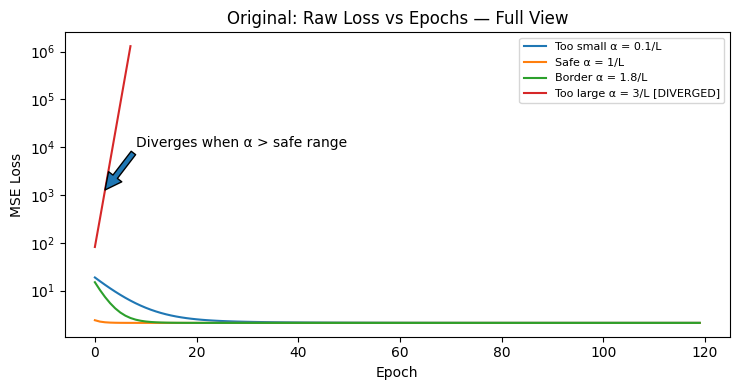

In [41]:
# ============================================================
# Plot A: ORIGINAL raw loss — full view (divergence visible)
# ============================================================
fig , ax = plt.subplots(1 , 1 , figsize = (7.5 , 4))
for label in ORDER:
    r = results_orig[label]
    ax.plot(r["losses"] , label = label + (" [DIVERGED]" if r["diverged"] else ""))

ax.set_title("Original: Raw Loss vs Epochs — Full View")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_yscale("symlog" , linthresh = 1)
ax.legend(fontsize = 8)

r_big = results_orig["Too large α = 3/L"]
if len(r_big["losses"]) > 2:
    idx = min(2 , len(r_big["losses"]) - 1)
    ax.annotate("Diverges when α > safe range" , xy = (idx , r_big["losses"][idx]) ,
                xytext = (8 , 1e4) , arrowprops = dict())

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Original: Zoom A — Slow vs Safe (Raw Loss)')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'MSE Loss')

(2.001108951779704, 3.101108951779704)

Text(0.02, 0.95, '1% to final: safe = 4 epochs , slow = 52 epochs')

Text(0.5, 1.0, 'Original: Zoom B — Safe vs Border (Raw Loss)')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'MSE Loss')

(1.101108951779704, 27.101108951779704)

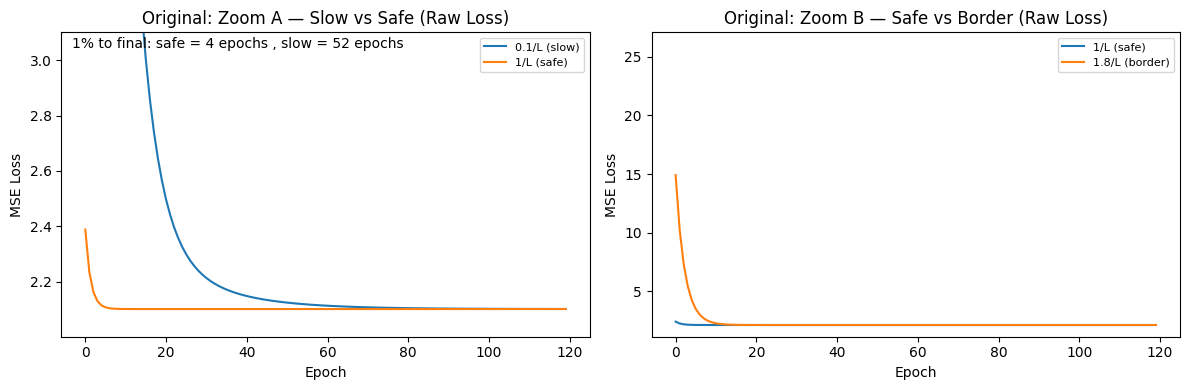

In [42]:
#=======================================================
# Plot B: MSE Loss vs Epoch
# Panel 1: Too small vs Safe (speed difference)
# Panel 2: Safe vs Border (near-boundary inefficiency)
# "1% to final" annotation on Zoom A
#=======================================================
fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4))

# Panel 1
ax = axes[0]
slow = results_orig["Too small α = 0.1/L"]
safe = results_orig["Safe α = 1/L"]

ax.plot(slow["losses"] , label = "0.1/L (slow)")
ax.plot(safe["losses"] , label = "1/L (safe)")

ax.set_title("Original: Zoom A — Slow vs Safe (Raw Loss)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_ylim(opt_loss_orig - 0.1 , opt_loss_orig + 1.0)

slow_t = epochs_to_tol(slow["losses"] , tol = 0.01) if not slow["diverged"] else None
safe_t = epochs_to_tol(safe["losses"] , tol=0.01) if not safe["diverged"] else None
ax.text(0.02 , 0.95 , f"1% to final: safe = {safe_t} epochs , slow = {slow_t} epochs" ,
        transform = ax.transAxes)
ax.legend(fontsize = 8)

# Panel 2
ax = axes[1]
border = results_orig["Border α = 1.8/L"]

ax.plot(safe["losses"] , label = "1/L (safe)")
ax.plot(border["losses"] , label = "1.8/L (border)")

ax.set_title("Original: Zoom B — Safe vs Border (Raw Loss)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_ylim(opt_loss_orig - 1.0 , opt_loss_orig + 25.0)
ax.legend(fontsize = 8)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Original: Zoom A — Distance to Optimum (ΔLoss)')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'ΔLoss')

(0.0, 5.0)

Text(0.5, 1.0, 'Original: Zoom B — Border Inefficiency (ΔLoss)')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'ΔLoss')

(0.0, 30.0)

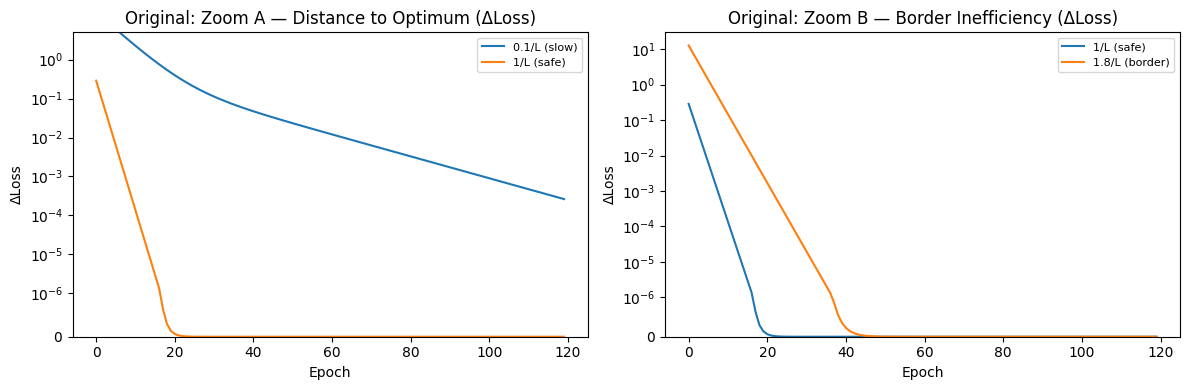

In [43]:
#======================================
# Plot C: Distance to optimum (ΔLoss)
#======================================
fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4))

# Panel 1
ax = axes[0]
ax.plot(delta_losses(slow["losses"] , opt_loss_orig) , label = "0.1/L (slow)")
ax.plot(delta_losses(safe["losses"] , opt_loss_orig) , label = "1/L (safe)")
ax.set_title("Original: Zoom A — Distance to Optimum (ΔLoss)")
ax.set_xlabel("Epoch")
ax.set_ylabel("ΔLoss")
ax.set_yscale("symlog" , linthresh = 1e-6)
ax.set_ylim(0 , 5)
ax.legend(fontsize = 8)

# Panel 2
ax = axes[1]
ax.plot(delta_losses(safe["losses"] , opt_loss_orig) , label = "1/L (safe)")
ax.plot(delta_losses(border["losses"] , opt_loss_orig) , label = "1.8/L (border)")
ax.set_title("Original: Zoom B — Border Inefficiency (ΔLoss)")
ax.set_xlabel("Epoch")
ax.set_ylabel("ΔLoss")
ax.set_yscale("symlog" , linthresh = 1e-6)
ax.set_ylim(0 , 30)
ax.legend(fontsize = 8)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Scaling Effect (First 20 Epochs): Correct L vs Wrong L')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'MSE Loss')

(2.001108951779704, 3.101108951779704)

Text(0.02, 0.95, '1% to final: orig = 4 , scaled-ok = 0 , scaled-wrong = 8')

<BarContainer object of 2 artists>

<BarContainer object of 2 artists>

[Text(0, 0, 'Original'), Text(1, 0, 'Scaled')]

Text(0.5, 1.0, 'Curvature Diagnostics: L and Safe Step (1/L)')

Text(0, 0.5, 'Value')

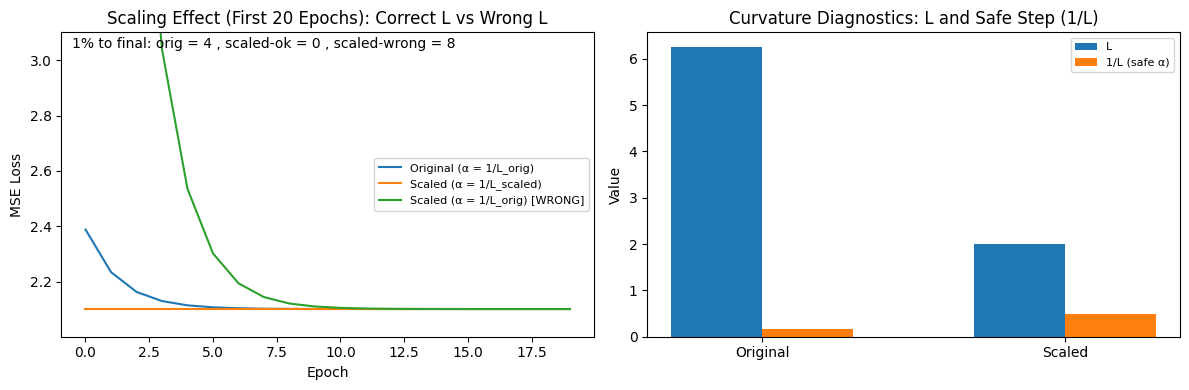

In [44]:
#=================================================
# Plot D: Scaling effect & Curvature Diagnostics
#=================================================
alpha_wrong_for_scaled = alpha_1_over_L_orig

_ , loss_scaled_correct , div_scaled_correct = run_gd(X_scaled_design , y , alpha_1_over_L_scaled , epochs = epochs)
_ , loss_scaled_wrong , div_scaled_wrong = run_gd(X_scaled_design , y , alpha_wrong_for_scaled , epochs = epochs)
EARLY = 20

fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4))

# Panel 1
ax = axes[0]
ax.plot(results_orig["Safe α = 1/L"]["losses"][ : EARLY] , label = "Original (α = 1/L_orig)")
ax.plot(loss_scaled_correct[ : EARLY] , label = "Scaled (α = 1/L_scaled)")
ax.plot(loss_scaled_wrong[ : EARLY] , label = "Scaled (α = 1/L_orig) [WRONG]")
ax.set_title(f"Scaling Effect (First {EARLY} Epochs): Correct L vs Wrong L")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_ylim(min(opt_loss_orig , opt_loss_scaled) - 0.1 , min(opt_loss_orig , opt_loss_scaled) + 1.0)

t_orig = epochs_to_tol(results_orig["Safe α = 1/L"]["losses"] , tol = 0.01)
t_sc_ok = epochs_to_tol(loss_scaled_correct , tol = 0.01)
t_sc_bad = epochs_to_tol(loss_scaled_wrong , tol = 0.01) if not div_scaled_wrong else None
ax.text(0.02 , 0.95 ,
        f"1% to final: orig = {t_orig} , scaled-ok = {t_sc_ok} , scaled-wrong = {t_sc_bad}" ,
        transform = ax.transAxes)
ax.legend(fontsize = 8)

# Panel 2
ax = axes[1]
bars = ["Original" , "Scaled"]
Ls = [L_orig , L_scaled]
safe_alphas = [alpha_1_over_L_orig , alpha_1_over_L_scaled]
xpos = np.arange(len(bars))
ax.bar(xpos - 0.15 , Ls , width = 0.3 , label = "L")
ax.bar(xpos + 0.15 , safe_alphas , width = 0.3 , label = "1/L (safe α)")
ax.set_xticks(xpos)
ax.set_xticklabels(bars)
ax.set_title("Curvature Diagnostics: L and Safe Step (1/L)")
ax.set_ylabel("Value")
ax.legend(fontsize = 8)

plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Final Fits — Fixed-Step Rules')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

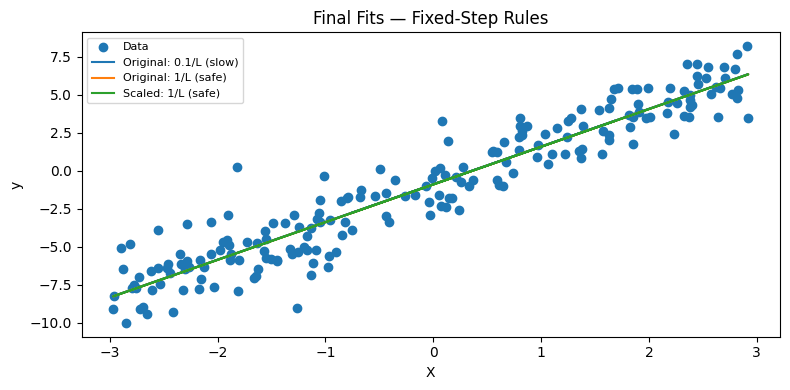

In [45]:
#=====================
# Plot E: Final fits
#=====================
def predict_line_originalX(w):
    return w[0] * X.flatten() + w[1]

plt.figure(figsize = (8 , 4))
plt.scatter(X , y , label = "Data")

w_slow = slow["w"]
w_safe = safe["w"]
plt.plot(X , predict_line_originalX(w_slow) , label = "Original: 0.1/L (slow)")
plt.plot(X , predict_line_originalX(w_safe) , label = "Original: 1/L (safe)")

w_scaled_safe = results_scaled["Safe α = 1/L"]["w"]
x_mean = X.mean()
x_std = X.std()
yhat_scaled_safe = w_scaled_safe[0] * ((X - x_mean) / x_std).flatten() + w_scaled_safe[1]
plt.plot(X , yhat_scaled_safe , label = "Scaled: 1/L (safe)")

plt.title("Final Fits — Fixed-Step Rules")
plt.xlabel("X")
plt.ylabel("y")
plt.legend(fontsize = 8)
plt.tight_layout()
plt.show()

In [46]:
#================================================
# Diagnostic summary + convergence speed metric
#================================================
print("=== Diagnostic Summary ===")
print(f"Noise SD used: {noise_sd:.2f}")
print(f"L (original): {L_orig:.4f} | safe α = 1/L: {alpha_1_over_L_orig:.4f} | border ~1.8/L: {1.8/L_orig:.4f}")
print(f"L (scaled)  : {L_scaled:.4f} | safe α = 1/L: {alpha_1_over_L_scaled:.4f} | border ~1.8/L: {1.8/L_scaled:.4f}")
print()

print("=== Original runs ===")
for k in ORDER:
    r = results_orig[k]
    status = "DIVERGED" if r["diverged"] else "OK"
    speed = epochs_to_tol(r["losses"] , tol = 0.01) if not r["diverged"] else "-"
    print(f"{k:22s} α = {r['alpha']:.4f} final_loss = {r['losses'][-1]:.4f}  epochs_to_1% = {speed}  [{status}]")

print("\n=== Scaled runs ===")
for k in ORDER:
    r = results_scaled[k]
    status = "DIVERGED" if r["diverged"] else "OK"
    speed = epochs_to_tol(r["losses"] , tol = 0.01) if not r["diverged"] else "-"
    print(f"{k:22s} α = {r['alpha']:.4f} final_loss = {r['losses'][-1]:.4f}  epochs_to_1% = {speed}  [{status}]")

print("\n=== Scaling sanity check (same data, different alpha rules on SCALED) ===")
print(f"Scaled with correct α = 1/L_scaled: final_loss = {loss_scaled_correct[-1]:.4f}  epochs_to_1% = {epochs_to_tol(loss_scaled_correct)}  [{'DIVERGED' if div_scaled_correct else 'OK'}]")
print(f"Scaled with WRONG   α = 1/L_orig  : final_loss = {loss_scaled_wrong[-1]:.4f}  epochs_to_1% = {epochs_to_tol(loss_scaled_wrong) if not div_scaled_wrong else '-'}  [{'DIVERGED' if div_scaled_wrong else 'OK'}]")

=== Diagnostic Summary ===
Noise SD used: 1.50
L (original): 6.2570 | safe α = 1/L: 0.1598 | border ~1.8/L: 0.2877
L (scaled)  : 2.0000 | safe α = 1/L: 0.5000 | border ~1.8/L: 0.9000

=== Original runs ===
Too small α = 0.1/L    α = 0.0160 final_loss = 2.1014  epochs_to_1% = 52  [OK]
Safe α = 1/L           α = 0.1598 final_loss = 2.1011  epochs_to_1% = 4  [OK]
Border α = 1.8/L       α = 0.2877 final_loss = 2.1011  epochs_to_1% = 15  [OK]
Too large α = 3/L      α = 0.4795 final_loss = 1300496.8934  epochs_to_1% = -  [DIVERGED]

=== Scaled runs ===
Too small α = 0.1/L    α = 0.0500 final_loss = 2.1011  epochs_to_1% = 32  [OK]
Safe α = 1/L           α = 0.5000 final_loss = 2.1011  epochs_to_1% = 0  [OK]
Border α = 1.8/L       α = 0.9000 final_loss = 2.1011  epochs_to_1% = 15  [OK]
Too large α = 3/L      α = 1.5000 final_loss = 1341027.1715  epochs_to_1% = -  [DIVERGED]

=== Scaling sanity check (same data, different alpha rules on SCALED) ===
Scaled with correct α = 1/L_scaled: final_loss